## Ghi chú

Cài đặt **Linear Regression** từ đầu (không dùng sklearn), huấn luyện bằng gradient descent:

- `predict(X) = X·w + b`
- Gradient của MSE theo `w`, `b` (trung bình trên toàn bộ batch)
- Learning rate decay theo epoch: `lr = lr0 / (1 + decay_rate * epoch)`
- Trực quan hóa đường hồi quy qua các epoch để thấy quá trình hội tụ

Epoch 10, Loss: 1.8469, LR: 0.068966
Epoch 20, Loss: 1.1692, LR: 0.051282
Epoch 30, Loss: 1.1257, LR: 0.040816
Epoch 40, Loss: 1.1081, LR: 0.033898
Epoch 50, Loss: 1.0957, LR: 0.028986
Epoch 60, Loss: 1.0858, LR: 0.025316
Epoch 70, Loss: 1.0778, LR: 0.022472
Epoch 80, Loss: 1.0710, LR: 0.020202
Epoch 90, Loss: 1.0652, LR: 0.018349
Epoch 100, Loss: 1.0601, LR: 0.016807


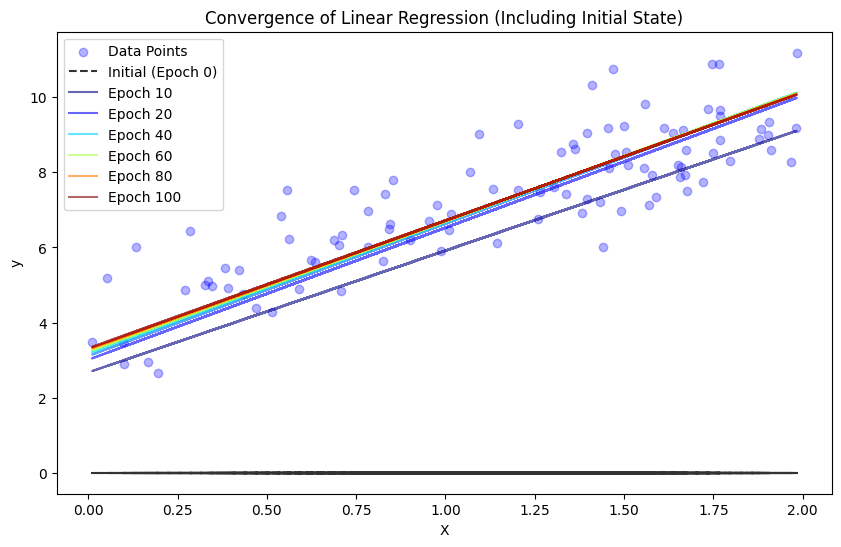

Final Weights: 3.4033, Bias: 3.3166


In [4]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegression:
    def __init__(self, learning_rate=0.01, decay_rate=0.01, epochs=100):
        self.lr = learning_rate
        self.decay_rate = decay_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def compute_gradients(self, X, y, y_pred):
        n_samples = X.shape[0]
        dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
        db = (1 / n_samples) * np.sum(y_pred - y)
        return dw, db

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        current_lr = self.lr

        # Khởi tạo biểu đồ duy nhất
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', alpha=0.3, label='Data Points')

        # Vẽ đường tại Epoch 0 (Lúc mới khởi tạo)
        y_init = self.predict(X)
        plt.plot(X, y_init, color='black', linestyle='--', alpha=0.8, label='Initial (Epoch 0)')

        colors = plt.cm.jet(np.linspace(0, 1, self.epochs // 10))
        color_idx = 0

        for epoch in range(self.epochs):
            y_pred = self.predict(X)
            dw, db = self.compute_gradients(X, y, y_pred)

            self.weights -= current_lr * dw
            self.bias -= current_lr * db

            current_lr = self.lr * (1.0 / (1.0 + self.decay_rate * epoch))

            if (epoch + 1) % 10 == 0:
                loss = np.mean((y_pred - y)**2)
                print(f'Epoch {epoch+1}, Loss: {loss:.4f}, LR: {current_lr:.6f}')

                # Vẽ đường dự đoán hiện tại
                plt.plot(X, y_pred, color=colors[color_idx], alpha=0.6,
                         label=f'Epoch {epoch+1}' if (epoch+1) % 20 == 0 or epoch==9 else "")
                color_idx += 1

        plt.title('Convergence of Linear Regression (Including Initial State)')
        plt.xlabel('X')
        plt.ylabel('y')
        plt.legend()
        plt.show()

if __name__ == '__main__':
    X = 2 * np.random.rand(100, 1)
    y = 4 + 3 * X.flatten() + np.random.randn(100)

    model = LinearRegression(learning_rate=0.1, decay_rate=0.05, epochs=100)
    model.fit(X, y)
    print(f'Final Weights: {model.weights[0]:.4f}, Bias: {model.bias:.4f}')